In [ ]:
import numpy as np
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt

In [ ]:
class KalmanTrack:
    def __init__(
        self,
        detection,
        track_id,
        object_id=None,
        Q_params=None,
        R_params=None
    ):
        '''
        Class for an individual track managed by a Kalman filter.

        detection: input measurement in format [x, y, z, yaw, w, h]
            where (x, y, z) are the 3D bounding box center coordinates,
            yaw is the rotation angle around the vertical axis,
            w is the width, h is the height of the 2D box

        track_id: unique ID assigned by the tracker to this track.

        object_id: ID — reference object ID from ground truth.

        Q_params, R_params: process noise (Q) and measurement noise (R) parameters
        '''
        self.id = track_id
        self.object_id = object_id

        # Initialize state vector x with size (10, 1)
        self.x = np.zeros((10, 1))
        self.x[0] = detection[0] # px = x from detection
        self.x[1] = detection[1] # py = y
        self.x[2] = detection[2] # pz = z
        self.x[6] = detection[3] # yaw
        self.x[8] = detection[4] # w (box width)
        self.x[9] = detection[5] # h (box height)

        # Initialize error matrix
        self.P = np.eye(10) * 10.0
        self.P[0, 0] = 1.0
        self.P[1, 1] = 1.0
        self.P[2, 2] = 1.0
        self.P[6, 6] = 1.0
        self.P[8, 8] = 1.0
        self.P[9, 9] = 1.0

        self.time_since_update = 0
        self.hits = 1
        self.state = 'tentative'

        # Set process noise parameters Q
        self.Q_params = Q_params or {
            'q_pos': 0.1,   # position uncertainty
            'q_vel': 1.0,   # velocity uncertainty
            'q_yaw': 0.1,   # yaw angle uncertainty
            'q_vyaw': 1.0,  # angular velocity uncertainty
            'q_size': 0.01  # box dimensions uncertainty
        }

        # Set measurement noise parameters R
        self.R_params = R_params or {
            'r_x': 0.2,   # x measurement noise
            'r_y': 0.2,   # y measurement noise
            'r_z': 0.5,   # z measurement noise
            'r_yaw': 0.1, # yaw measurement noise
            'r_w': 0.05,  # box width measurement noise
            'r_h': 0.05   # box height measurement noise
        }

    # Get the state transition matrix F
    def get_F(self, dt):
        F = np.eye(10)
        F[0, 3] = dt
        F[1, 4] = dt
        F[2, 5] = dt
        F[6, 7] = dt
        return F

    # Get the process noise matrix Q
    def get_Q(self, dt):
        Q = np.diag([
            self.Q_params['q_pos'] * dt,  # px
            self.Q_params['q_pos'] * dt,  # py
            self.Q_params['q_pos'] * dt,  # pz
            self.Q_params['q_vel'] * dt,  # vx
            self.Q_params['q_vel'] * dt,  # vy
            self.Q_params['q_vel'] * dt,  # vz
            self.Q_params['q_yaw'] * dt,  # yaw
            self.Q_params['q_vyaw'] * dt,  # vyaw
            self.Q_params['q_size'] * dt,  # w
            self.Q_params['q_size'] * dt,  # h
        ])
        return Q

    # Get the observation matrix H
    def get_H(self):
        H = np.zeros((6, 10))
        H[0, 0] = 1
        H[1, 1] = 1
        H[2, 2] = 1
        H[3, 6] = 1
        H[4, 8] = 1
        H[5, 9] = 1
        return H

    # Get the measurement noise matrix R
    def get_R(self):
        R = np.diag([
            self.R_params['r_x'],
            self.R_params['r_y'],
            self.R_params['r_z'],
            self.R_params['r_yaw'],
            self.R_params['r_w'],
            self.R_params['r_h']
        ])
        return R

    def predict(self, dt=1.0):
        F = self.get_F(dt)
        Q = self.get_Q(dt)
        self.x = F @ self.x
        self.P = F @ self.P @ F.T + Q
        self.time_since_update += 1

    def update(self, detection, object_id=None, max_vel=2.0):
        '''
        Update step.
        Corrects the predicted state based on a new measurement.

        detection: new measurement [x, y, z, yaw, w, h]
        object_id: ID (for evaluation)
        max_vel: maximum allowed velocity

        Returns:
        True if update is accepted
        False if update is rejected (e.g., due to excessive velocity)
        '''
        H = self.get_H()
        R = self.get_R()

        z = detection.reshape(6, 1)
        y = z - H @ self.x
        S = H @ self.P @ H.T + R
        K = self.P @ H.T @ np.linalg.inv(S)
        x_new = self.x + K @ y

        if abs(float(x_new[3, 0])) > max_vel \
            or abs(float(x_new[4, 0])) > max_vel \
            or abs(float(x_new[5, 0])) > max_vel \
            or abs(float(x_new[7, 0])) > 1.0:
            return False
        
        self.x = x_new

        I = np.eye(10)
        self.P = (I - K @ H) @ self.P

        self.time_since_update = 0
        self.hits += 1

        if object_id is not None:
            self.object_id = object_id

        return True

In [ ]:
def get_rect_min_max_cord(box):
    cx, cy, w, h = box
    xmin = cx - w / 2.0
    ymin = cy - h / 2.0
    xmax = cx + w / 2.0
    ymax = cy + h / 2.0
    return xmin, ymin, xmax, ymax


def rect_iou(track_box, det_box):
    xmin1, ymin1, xmax1, ymax1 = get_rect_min_max_cord(track_box)
    xmin2, ymin2, xmax2, ymax2 = get_rect_min_max_cord(det_box)

    inter_xmin = max(xmin1, xmin2)
    inter_ymin = max(ymin1, ymin2)
    inter_xmax = min(xmax1, xmax2)
    inter_ymax = min(ymax1, ymax2)

    inter_w = max(0.0, inter_xmax - inter_xmin)
    inter_h = max(0.0, inter_ymax - inter_ymin)
    inter_area = inter_w * inter_h

    area1 = max(0.0, xmax1 - xmin1) * max(0.0, ymax1 - ymin1)
    area2 = max(0.0, xmax2 - xmin2) * max(0.0, ymax2 - ymin2)

    union = area1 + area2 - inter_area
    return inter_area / union if union > 0 else 0.0


def compute_cost_matrix(tracks, detections):
    N = len(tracks)
    M = len(detections)

    C = np.zeros((N, M))

    for i, track in enumerate(tracks):

        tx = float(track.x[0, 0])
        ty = float(track.x[1, 0])
        tw = float(track.x[8, 0])
        th = float(track.x[9, 0])
        tyaw = float(track.x[6, 0])

        track_box = np.array([tx, ty, tw, th])

        for j, det in enumerate(detections):
            det_box = det[:4]
            det_yaw = det[3]

            iou = rect_iou(track_box, det_box)
            yaw_diff = min(
                abs(tyaw - det_yaw), 
                (2 * np.pi - abs(tyaw - det_yaw))
            )
            yaw_cost = yaw_diff / np.pi

            C[i, j] = (1.0 - iou) + 0.2 * yaw_cost

    return C

In [ ]:
class Tracker:
    def __init__(
        self, 
        max_age=5, 
        match_threshold=0.7,
        min_hits=3,
        max_vel=2.0,
        Q_params=None,
        R_params=None
    ):
        '''
        Main tracker class that manages the lifecycle of all tracks.

        max_age: how many steps a track can live without updates
        match_threshold: threshold for accepting a match
        min_hits: number of consecutive updates required to confirm a track
        max_vel: maximum allowed velocity
        Q_params, R_params: noise parameters for new tracks
        '''
        self.tracks = []
        self.next_id = 0
        self.max_age = max_age
        self.match_threshold = match_threshold
        self.min_hits = min_hits
        self.max_vel = max_vel
        self.Q_params = Q_params
        self.R_params = R_params

    def step(self, detections, dt=1.0):
        for tr in self.tracks:
            tr.predict(dt)

        if not detections:
            self.tracks = [t for t in self.tracks if t.time_since_update < self.max_age]
            return
        
        det_arrays = [d[0] for d in detections]
        det_object_ids = [d[1] for d in detections]

        assigned_dets = set()
        if self.tracks:
            C = compute_cost_matrix(self.tracks, det_arrays)
            row_ind, col_ind = linear_sum_assignment(C)

            for r, c in zip(row_ind, col_ind):
                if C[r, c] < self.match_threshold:
                    success = self.tracks[r].update(
                        det_arrays[c],
                        object_id=det_object_ids[c],
                        max_vel=self.max_vel
                    )
                    if success:
                        assigned_dets.add(c)

        for j, (det_arr, object_id) in enumerate(detections):
            if j not in assigned_dets:
                new_track = KalmanTrack(
                    det_arr, 
                    self.next_id, 
                    object_id=object_id, 
                    Q_params=self.Q_params,
                    R_params=self.R_params
                )
                if new_track.update(det_arr, object_id=object_id, max_vel=self.max_vel):
                    self.tracks.append(new_track)
                    self.next_id += 1

        self.tracks = [
            t for t in self.tracks 
            if t.time_since_update < self.max_age
        ]

        for tr in self.tracks:
            if tr.hits >= self.min_hits:
                tr.state = 'confirmed'

In [ ]:
def generate_objects(
    num_objs=5, T=200, add_noise=True, noise_level=0.1, random_seed=None
):
    '''
    Simulate 3-5 moving objects with curved trajectories and measurement noise.
    
    num_objs: number of objects (3-5 recommended)
    T: number of time steps
    add_noise: whether to add measurement noise
    noise_level: standard deviation of noise
    
    Returns:
    true_states: dictionary of ground truth states [x, y, z, yaw, w, h, vx, vy]
    measurements: dictionary of noisy measurements [x, y, z, yaw, w, h]
    '''
    true_states = {}
    measurements = {}
    np.random.seed(random_seed)
    
    for obj_id in range(num_objs):
        # Different starting positions across the scene
        if obj_id == 0:  # 1: top-left, moving right-down
            cx0, cy0 = -8.0, 5.0
            vx, vy = 0.15, -0.08
            yaw0 = 0.2
        elif obj_id == 1:  # 2: bottom-right, moving left-up
            cx0, cy0 = 8.0, -5.0
            vx, vy = -0.12, 0.1
            yaw0 = -0.3
        elif obj_id == 2:  # 3: center, moving circular
            cx0, cy0 = 0.0, 0.0
            vx, vy = 0.1, 0.05
            yaw0 = 0.5
        elif obj_id == 3:  # 4: left-bottom, moving right-up
            cx0, cy0 = -5.0, -4.0
            vx, vy = 0.08, 0.12
            yaw0 = -0.1
        else:  # 5: right-top, moving left-down
            cx0, cy0 = 6.0, 6.0
            vx, vy = -0.1, -0.07
            yaw0 = 0.4
        
        z0 = 1.0  # Constant height
        w0 = np.random.uniform(1.0, 1.8)
        h0 = np.random.uniform(1.5, 2.2)
        
        # Different oscillation parameters for curved trajectories
        freq_x = np.random.uniform(0.1, 0.3)
        freq_y = np.random.uniform(0.1, 0.3)
        amp_x = np.random.uniform(1.0, 3.0)
        amp_y = np.random.uniform(1.0, 3.0)
        
        states = []
        noisy_measurements = []
        
        for t in range(T):
            # Creates curved paths (spiral, sine wave, circular-like)
            cx = cx0 + vx * t + amp_x * np.sin(freq_x * t + obj_id)
            cy = cy0 + vy * t + amp_y * np.cos(freq_y * t + obj_id * 0.5)
            
            # Yaw changes over time (rotation)
            yaw = yaw0 + 0.02 * t + 0.1 * np.sin(0.1 * t)
            
            # Box dimensions with small variations
            w = max(0.5, w0 + 0.1 * np.sin(0.2 * t + obj_id))
            h = max(0.5, h0 + 0.1 * np.cos(0.15 * t + obj_id))
            
            # True state [x, y, z, yaw, w, h, vx, vy]
            true_state = np.array([cx, cy, z0, yaw, w, h, vx, vy])
            states.append(true_state)
            
            # Add measurement noise if requested
            if add_noise:
                # Noisy measurement [x, y, z, yaw, w, h]
                noise = np.random.normal(0, noise_level, 6)
                # Add larger noise to z and yaw as they're harder to measure
                noise[2] *= 2  # z noise
                noise[3] *= 1.5  # yaw noise
                
                noisy_meas = true_state[:6] + noise
                noisy_measurements.append(noisy_meas)
            else:
                noisy_measurements.append(true_state[:6])
        
        true_states[obj_id] = states
        measurements[obj_id] = noisy_measurements
    
    return true_states, measurements

In [ ]:
def plot_trajectories(true_states, measurements=None):
    '''
    Simple plotting function to visualize trajectories
    '''
    
    plt.figure(figsize=(10, 8))
    
    for obj_id in true_states:
        states = np.array(true_states[obj_id])
        plt.plot(states[:, 0], states[:, 1], 'o-', markersize=3, 
                label=f'Object {obj_id} (true)', alpha=0.7)
        
        if measurements is not None:
            meas = np.array(measurements[obj_id])
            plt.plot(meas[:, 0], meas[:, 1], 'x', markersize=2,
                    label=f'Object {obj_id} (noisy)', alpha=0.5)
    
    plt.xlabel('X position')
    plt.ylabel('Y position')
    plt.title('Object Trajectories')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

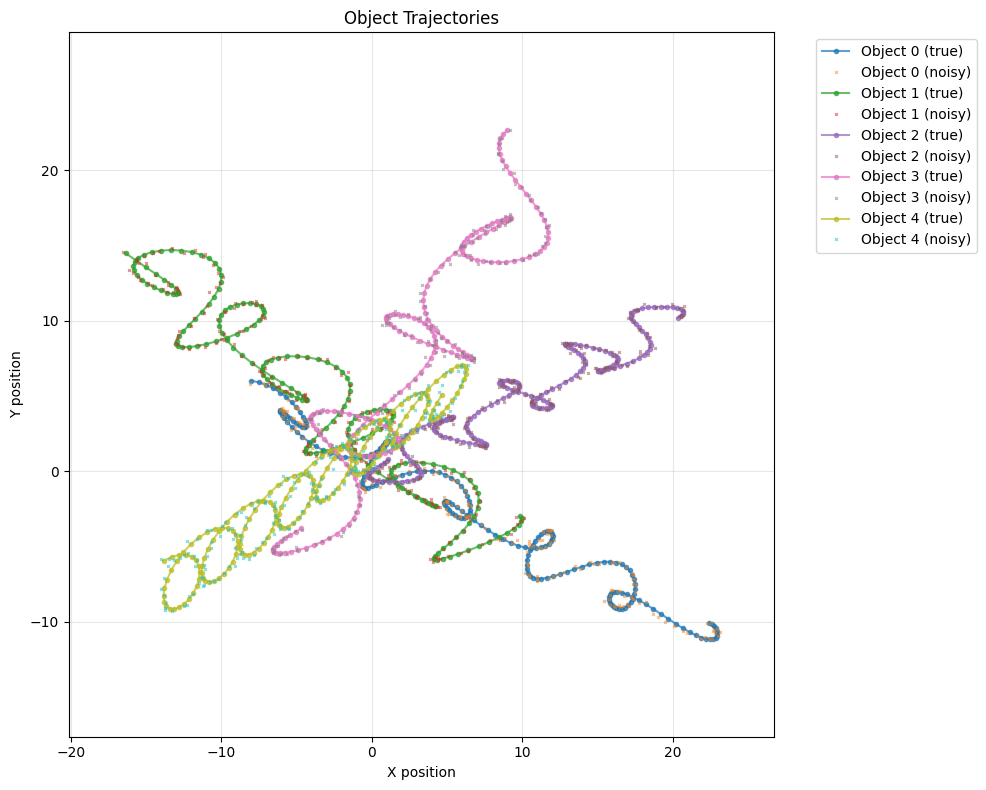

In [ ]:
true_states, measurements = generate_objects(num_objs=5, T=200, noise_level=0.15)
plot_trajectories(true_states, measurements)

In [ ]:
def exec(
    num_objs=5,
    T=300,
    pos_noise_std=0.2,
    size_noise_std=0.05,
    yaw_noise_std=0.05,
    match_threshold=0.6,
    max_age=10,
    min_hits=3,
    max_vel=2.0,
    Q_params=None,
    R_params=None,
    show_plot=True,
    random_seed=None
):
    '''
    Run tracking experiment with simulated objects.
    
    num_objs: number of objects (3-5 recommended)
    T: number of time steps
    pos_noise_std: standard deviation for position noise (x, y)
    size_noise_std: standard deviation for box dimensions noise (w, h)
    yaw_noise_std: standard deviation for yaw angle noise
    match_threshold: threshold for accepting a match
    max_age: maximum steps a track can live without updates
    min_hits: minimum hits to confirm a track
    max_vel: maximum allowed velocity
    Q_params: process noise parameters for Kalman filter
    R_params: measurement noise parameters for Kalman filter
    show_plot: whether to display trajectory plot
    random_seed: seed for reproducibility (optional)
    
    Returns:
    Dictionary with evaluation metrics
    '''
    
    # Set random seed if provided
    if random_seed is not None:
        np.random.seed(random_seed)
    
    # Generate ground truth trajectories (no noise)
    true_states, _ = generate_objects(
        num_objs=num_objs, T=T, add_noise=False, random_seed=random_seed
    )
    
    # Generate noisy detections for each time step
    detections_all = []
    for t in range(T):
        dets = []
        for obj_id in range(num_objs):
            # Get ground truth state at time t
            s = true_states[obj_id][t]
            cx, cy, z, yaw, w, h = s[0], s[1], s[2], s[3], s[4], s[5]
            
            # Add measurement noise
            noisy = np.array([
                cx + np.random.normal(0, pos_noise_std),        # x with noise
                cy + np.random.normal(0, pos_noise_std),        # y with noise
                z + np.random.normal(0, 0.05),                   # z with small noise
                yaw + np.random.normal(0, yaw_noise_std),        # yaw with noise
                max(0.1, w + np.random.normal(0, size_noise_std)),  # width with noise
                max(0.1, h + np.random.normal(0, size_noise_std)),  # height with noise
            ])
            dets.append((noisy, obj_id))
        detections_all.append(dets)
    
    # Initialize tracker
    tracker = Tracker(
        max_age=max_age,
        match_threshold=match_threshold,
        min_hits=min_hits,
        max_vel=max_vel,
        Q_params=Q_params,
        R_params=R_params
    )
    
    # Initialize metrics
    total_position_error = 0.0
    total_velocity_error = 0.0
    matched_count = 0
    total_assignments = 0
    correct_assignments = 0
    id_switches = 0
    last_track_for_obj = {obj_id: None for obj_id in range(num_objs)}
    est_positions_by_obj = {obj_id: [] for obj_id in range(num_objs)}
    
    # Main tracking loop
    for t in range(T):
        dets = detections_all[t]
        tracker.step(dets, dt=1.0)
        
        # Filter only confirmed tracks
        confirmed_tracks = [tr for tr in tracker.tracks if tr.state == 'confirmed']
        
        if confirmed_tracks and dets:
            # Compute cost matrix and perform association
            C = compute_cost_matrix(confirmed_tracks, [d[0] for d in dets])
            row_ind, col_ind = linear_sum_assignment(C)
            
            for r, c in zip(row_ind, col_ind):
                if C[r, c] < tracker.match_threshold:
                    total_assignments += 1
                    tr = confirmed_tracks[r]
                    _, object_id = dets[c]
                    
                    # Check correct association
                    if tr.object_id == object_id:
                        correct_assignments += 1
                    
                    # Calculate position error
                    est_pos = np.array([float(tr.x[0, 0]), float(tr.x[1, 0])])
                    obj_pos = np.array([
                        float(true_states[object_id][t][0]), 
                        float(true_states[object_id][t][1])
                    ])
                    total_position_error += np.abs(est_pos - obj_pos).mean()
                    
                    # Calculate velocity error
                    est_vel = np.array([float(tr.x[3, 0]), float(tr.x[4, 0])])
                    obj_vel = np.array([
                        float(true_states[object_id][t][6]), 
                        float(true_states[object_id][t][7])
                    ])
                    total_velocity_error += np.abs(est_vel - obj_vel).mean()
                    
                    matched_count += 1
                    
                    # Count ID switches
                    last = last_track_for_obj[object_id]
                    if last is not None and last != tr.id:
                        id_switches += 1
                    last_track_for_obj[object_id] = tr.id
        
        # Save estimated positions for visualization
        for obj_id in range(num_objs):
            found = None
            for tr in tracker.tracks:
                if tr.state == 'confirmed' and tr.object_id == obj_id:
                    found = tr
                    break
            if found is not None:
                est_positions_by_obj[obj_id].append((float(found.x[0, 0]), float(found.x[1, 0])))
            else:
                est_positions_by_obj[obj_id].append((np.nan, np.nan))
    
    # Calculate final metrics
    mae_pos = total_position_error / matched_count if matched_count > 0 else np.nan
    mae_vel = total_velocity_error / matched_count if matched_count > 0 else np.nan
    matching_accuracy = correct_assignments / total_assignments if total_assignments > 0 else np.nan
    
    # Print results
    print("=" * 60)
    print("TRACKING EXPERIMENT RESULTS")
    print("=" * 60)
    print(f"Timesteps: {T}, Objects: {num_objs}")
    print(f"Noise levels: pos={pos_noise_std}, yaw={yaw_noise_std}, size={size_noise_std}")
    print(f"Tracker params: max_age={max_age}, threshold={match_threshold}, min_hits={min_hits}")
    print("-" * 60)
    print(f"Matched assignments: {matched_count}")
    print(f"Position MAE: {mae_pos:.4f}")
    print(f"Velocity MAE: {mae_vel:.4f}")
    print(f"Matching accuracy: {matching_accuracy * 100:.2f}% ({correct_assignments}/{total_assignments})")
    print(f"ID switches: {id_switches}")
    print("=" * 60)
    
    # Visualization
    if show_plot:
        plt.figure(figsize=(14, 10))
        colors = plt.cm.tab10(np.linspace(0, 1, num_objs))
        
        for obj_id in range(num_objs):
            color = colors[obj_id]
            
            # Plot true trajectory
            true_traj = np.array([true_states[obj_id][t][:2] for t in range(T)])
            plt.plot(true_traj[:, 0], true_traj[:, 1], '-', linewidth=2, 
                    color=color, label=f"Object {obj_id} (true)", alpha=0.8)
            
            # Plot estimated trajectory
            est_traj = np.array(est_positions_by_obj[obj_id])
            plt.plot(est_traj[:, 0], est_traj[:, 1], 'x--', linewidth=1.5, 
                    color=color, label=f"Object {obj_id} (estimated)", alpha=0.6, markersize=4)
            
            # Mark start and end points
            plt.plot(true_traj[0, 0], true_traj[0, 1], 'o', color=color, markersize=8)
            plt.plot(true_traj[-1, 0], true_traj[-1, 1], 's', color=color, markersize=8)
        
        plt.xlabel("X position", fontsize=12)
        plt.ylabel("Y position", fontsize=12)
        plt.title("True vs Estimated Trajectories", fontsize=14)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.axis('equal')
        plt.tight_layout()
        plt.show()
    
    return {
        'mae_pos': mae_pos,
        'mae_vel': mae_vel,
        'matching_accuracy': matching_accuracy,
        'id_switches': id_switches,
        'matched_assignments': matched_count,
        'total_assignments': total_assignments,
        'correct_assignments': correct_assignments
    }

In [114]:
import pandas as pd

def get_noise_configurations():
    '''
    Get different detection params Q и R
    '''
    configs = {}
    
    configs['low_Q_high_R'] = {
        'name': 'Low model noise / high detector noise',
        'Q_params': {
            'q_pos': 0.01,   # low position uncertainty
            'q_vel': 0.05,   # low velocity uncertainty
            'q_yaw': 0.01,   # low yaw uncertainty
            'q_vyaw': 0.05,  # low angular velocity uncertainty
            'q_size': 0.001  # low size uncertainty
        },
        'R_params': {
            'r_x': 0.5,      # high noise in x measurement
            'r_y': 0.5,      # high noise in y measurement
            'r_z': 0.5,      # high noise in z measurement
            'r_yaw': 0.3,    # high noise in yaw measurement
            'r_w': 0.2,      # high noise in width
            'r_h': 0.2       # high noise in height
        }
    }
    
    configs['high_Q_low_R'] = {
        'name': 'High model noise / low detector noise',
        'Q_params': {
            'q_pos': 0.5, 
            'q_vel': 2.0, 
            'q_yaw': 0.3, 
            'q_vyaw': 1.0,
            'q_size': 0.1 
        },
        'R_params': {
            'r_x': 0.05,  
            'r_y': 0.05,  
            'r_z': 0.05,  
            'r_yaw': 0.02,
            'r_w': 0.01,     
            'r_h': 0.01      
        }
    }
    
    configs['balanced'] = {
        'name': 'Balanced noise',
        'Q_params': {
            'q_pos': 0.1,
            'q_vel': 1.0,
            'q_yaw': 0.1,
            'q_vyaw': 1.0,
            'q_size': 0.01
        },
        'R_params': {
            'r_x': 0.2,
            'r_y': 0.2,
            'r_z': 0.5,
            'r_yaw': 0.1,
            'r_w': 0.05,
            'r_h': 0.05
        }
    }
    
    configs['high_yaw_noise'] = {
        'name': 'High yaw noise',
        'Q_params': {
            'q_pos': 0.1,
            'q_vel': 1.0,
            'q_yaw': 2.0, 
            'q_vyaw': 5.0,
            'q_size': 0.01
        },
        'R_params': {
            'r_x': 0.2,
            'r_y': 0.2,
            'r_z': 0.5,
            'r_yaw': 1.5,
            'r_w': 0.05,
            'r_h': 0.05
        }
    }
    
    configs['low_yaw_noise'] = {
        'name': 'Low yaw noise',
        'Q_params': {
            'q_pos': 0.1,
            'q_vel': 1.0,
            'q_yaw': 0.001, 
            'q_vyaw': 0.005,
            'q_size': 0.01
        },
        'R_params': {
            'r_x': 0.2,
            'r_y': 0.2,
            'r_z': 0.5,
            'r_yaw': 0.005,
            'r_w': 0.05,
            'r_h': 0.05
        }
    }
    
    configs['extremely_rigid'] = {
        'name': 'Extremely rigid (almost doesn\'t believe the measurements)',
        'Q_params': {
            'q_pos': 0.001,
            'q_vel': 0.001,
            'q_yaw': 0.001,
            'q_vyaw': 0.001,
            'q_size': 0.001
        },
        'R_params': {
            'r_x': 1.0,
            'r_y': 1.0,
            'r_z': 1.0,
            'r_yaw': 1.0,
            'r_w': 1.0,
            'r_h': 1.0
        }
    }
    
    configs['extremely_flexible'] = {
        'name': 'Extremely flexible model (completely trusts measurements)',
        'Q_params': {
            'q_pos': 5.0,
            'q_vel': 10.0,
            'q_yaw': 5.0,
            'q_vyaw': 10.0,
            'q_size': 1.0
        },
        'R_params': {
            'r_x': 0.001,
            'r_y': 0.001,
            'r_z': 0.001,
            'r_yaw': 0.001,
            'r_w': 0.001,
            'r_h': 0.001
        }
    }
    
    return configs

def analyze_yaw_behavior(
    results_dict, 
    config_name, 
    true_states, 
    t_range=100
):
    '''
    Analyzes yaw behavior for a specific configuration
    '''
    yaw_errors = []
    yaw_rates = []
    
    for obj_id in range(len(true_states)):
        obj_errors = []
        for t in range(min(t_range, len(results_dict.get('est_yaw', [])))):
            if t < len(true_states[obj_id]):
                true_yaw = true_states[obj_id][t][3]
                if obj_id in results_dict.get('est_yaw', {}):
                    est_yaw = results_dict['est_yaw'][obj_id][t] if t < len(results_dict['est_yaw'][obj_id]) else 0

                    error = min(abs(true_yaw - est_yaw), 
                              2*np.pi - abs(true_yaw - est_yaw))
                    
                    obj_errors.append(error)
        if obj_errors:
            yaw_errors.append(np.mean(obj_errors))
    
    return {
        'mean_yaw_error': np.mean(yaw_errors) if yaw_errors else np.nan,
        'yaw_std': np.std(yaw_errors) if yaw_errors else np.nan
    }

def run_noise_experiments(
    num_objs=4, T=200, random_seed=42
):
    '''
    Runs experiments for all noise configurations
    '''
    np.random.seed(random_seed)
    configs = get_noise_configurations()
    
    true_states, _ = generate_objects(
        num_objs=num_objs, 
        T=T, 
        add_noise=False,
        random_seed=random_seed
    )
    
    results = {}
    
    for config_key, config in configs.items():
        print(f'\n{"="*80}')
        print(f'CONF: {config["name"]}')
        print(f'{"="*80}')
        
        results[config_key] = {
            'name': config['name'],
            'multi_object': {}
        }
        
        res_multi = exec(
            num_objs=num_objs,
            T=T,
            pos_noise_std=0.2,
            yaw_noise_std=0.1,
            size_noise_std=0.05,
            match_threshold=0.7,
            max_age=10,
            min_hits=3,
            max_vel=3.0,
            Q_params=config['Q_params'],
            R_params=config['R_params'],
            show_plot=True,
            random_seed=random_seed
        )
        results[config_key]['multi_object'] = res_multi
    
    return results, true_states

def create_comparison_report(results):
    report_data = []
    
    for _, data in results.items():
        row = {
            'Conf': data['name'],
            'MAE pos': data['multi_object'].get('mae_pos', np.nan),
            'MAE vel': data['multi_object'].get('mae_vel', np.nan),
            'MAE acc%': data['multi_object'].get('matching_accuracy', np.nan) * 100,
            'ID switches': data['multi_object'].get('id_switches', np.nan),
        }
        report_data.append(row)
    
    df = pd.DataFrame(report_data)
    return df

def print_analysis_conclusions(results):
    print('\n' + '='*100)
    print('PRINT CONCLUSION')
    print('='*100)
    
    for config_key, data in results.items():
        print(f'\n--- {data["name"]} ---')
        
        multi = data['multi_object']
        
        print('\n~> Is association stability:', end=' ')
        if multi['matching_accuracy'] > 0.95:
            print('YES GREEN (association >95%)')
        elif multi['matching_accuracy'] > 0.85:
            print('YES YELLOW (association >85%)')
        else:
            print(f'NO RED (accuarcy {multi["matching_accuracy"]*100:.1f}%)')
        
        print('\n~> Does it confuses objects and assigns them incorrect IDs:', end=' ')
        if multi['id_switches'] > 5:
            print(f"YELLO (much switches: {multi['id_switches']})")
        else:
            print(f"GREEN (not much switches: {multi['id_switches']})")


        print('\n~> yaw:', end=' ')
        if 'high_yaw' in config_key:
            print('YELLOW (high variability)')
        elif 'low_yaw' in config_key:
            print('GREEN (a stable, but possibly delayed)')
        
        print('\n~> Tracker characteristics:', end=' ')
        if 'rigid' in config_key or 'low_Q' in config_key:
            print('Hard (smooths out noise, but can be delayed)')
        elif 'flexible' in config_key or 'high_Q' in config_key:
            print('Flexible (responds quickly, but can shake)')
        else:
            print('Balanced')


def print_analysis_conclusions(results):
    """
    Создает DataFrame с выводами по результатам экспериментов
    """
    print('\n' + '='*100)
    print('PRINT CONCLUSION')
    print('='*100)
    
    conclusion_data = []
    
    for config_key, data in results.items():
        multi = data['multi_object']
        
        if multi['matching_accuracy'] > 0.95:
            assoc_stability = 'GREEN (association >95%)'
        elif multi['matching_accuracy'] > 0.85:
            assoc_stability = 'YELLOW (association >85%)'
        else:
            assoc_stability = f"RED (accuracy {multi['matching_accuracy']*100:.1f}%)"
        
        if multi['id_switches'] > 5:
            id_issue = f"YELLOW (much switches: {multi['id_switches']})"
        else:
            id_issue = f"GREEN (not much switches: {multi['id_switches']})"
        
        if 'high_yaw' in config_key:
            yaw_behavior = 'YELLOW (high variability)'
        elif 'low_yaw' in config_key:
            yaw_behavior = 'GREEN (stable, but possibly delayed)'
        else:
            yaw_behavior = 'NORMAL'
        
        if 'rigid' in config_key or 'low_Q' in config_key:
            tracker_char = 'Hard (smooths out noise, but can be delayed)'
        elif 'flexible' in config_key or 'high_Q' in config_key:
            tracker_char = 'Flexible (responds quickly, but can shake)'
        else:
            tracker_char = 'Balanced'
        
        conclusion_data.append({
            'conf': data['name'],
            'assoc_stability': assoc_stability,
            'id_switches': multi['id_switches'],
            'id_issue': id_issue,
            'yaw_behavior': yaw_behavior,
            'tracker_char': tracker_char,
            'matching_accuracy': f"{multi['matching_accuracy']*100:.1f}%",
        })
    
    df = pd.DataFrame(conclusion_data)
    
    return df

STAR EXCPERIMENTS

CONF: Low model noise / high detector noise
TRACKING EXPERIMENT RESULTS
Timesteps: 200, Objects: 4
Noise levels: pos=0.2, yaw=0.1, size=0.05
Tracker params: max_age=10, threshold=0.7, min_hits=3
------------------------------------------------------------
Matched assignments: 489
Position MAE: 0.1458
Velocity MAE: 0.1889
Matching accuracy: 100.00% (489/489)
ID switches: 145


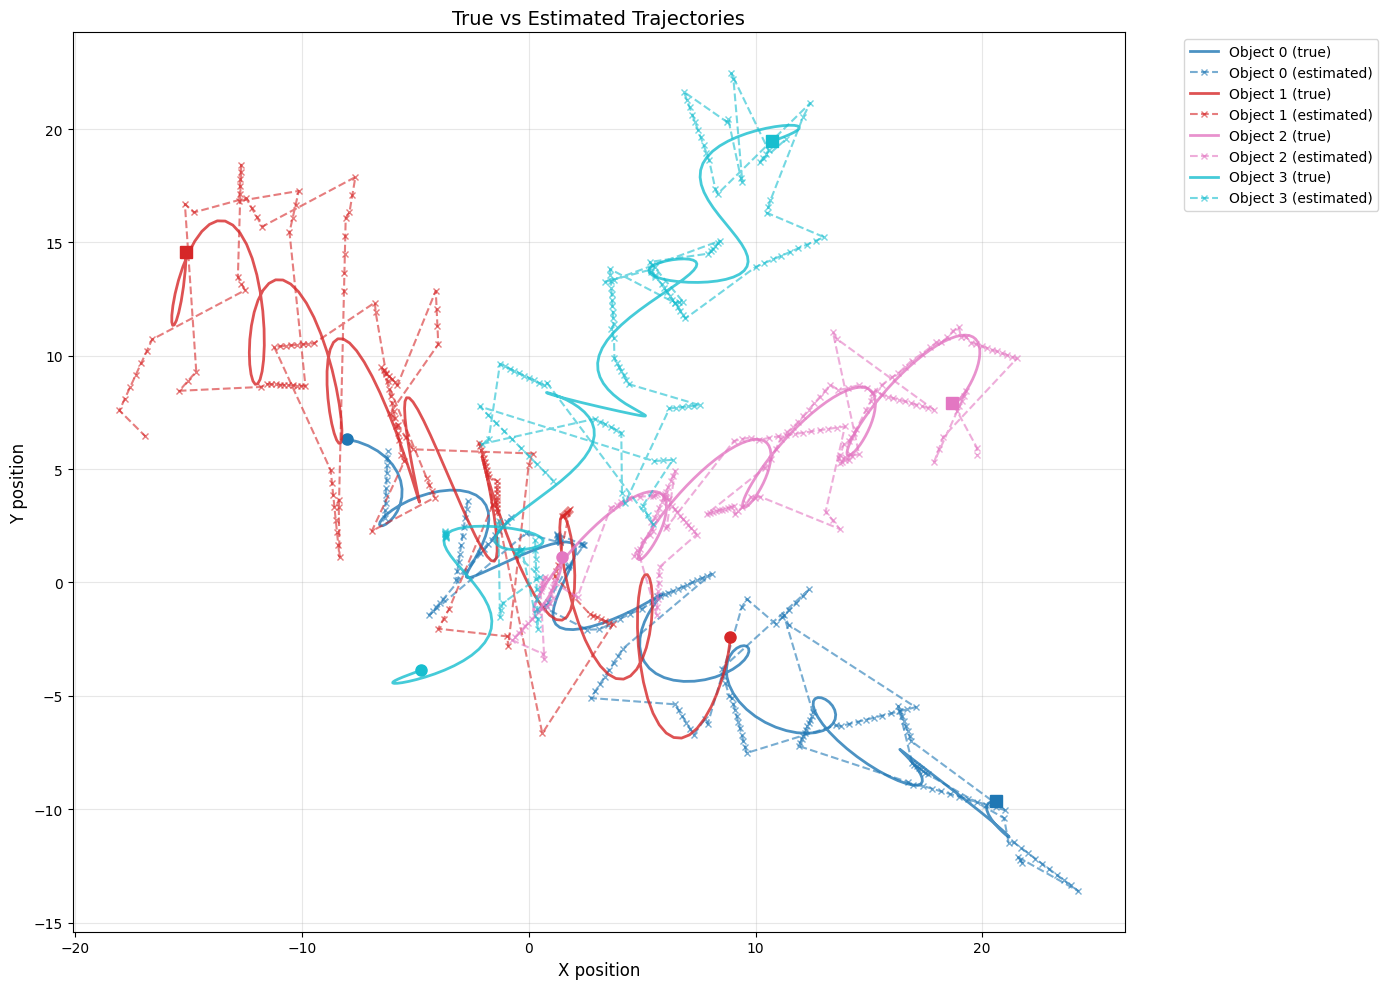


CONF: High model noise / low detector noise
TRACKING EXPERIMENT RESULTS
Timesteps: 200, Objects: 4
Noise levels: pos=0.2, yaw=0.1, size=0.05
Tracker params: max_age=10, threshold=0.7, min_hits=3
------------------------------------------------------------
Matched assignments: 459
Position MAE: 0.1541
Velocity MAE: 0.2254
Matching accuracy: 100.00% (459/459)
ID switches: 157


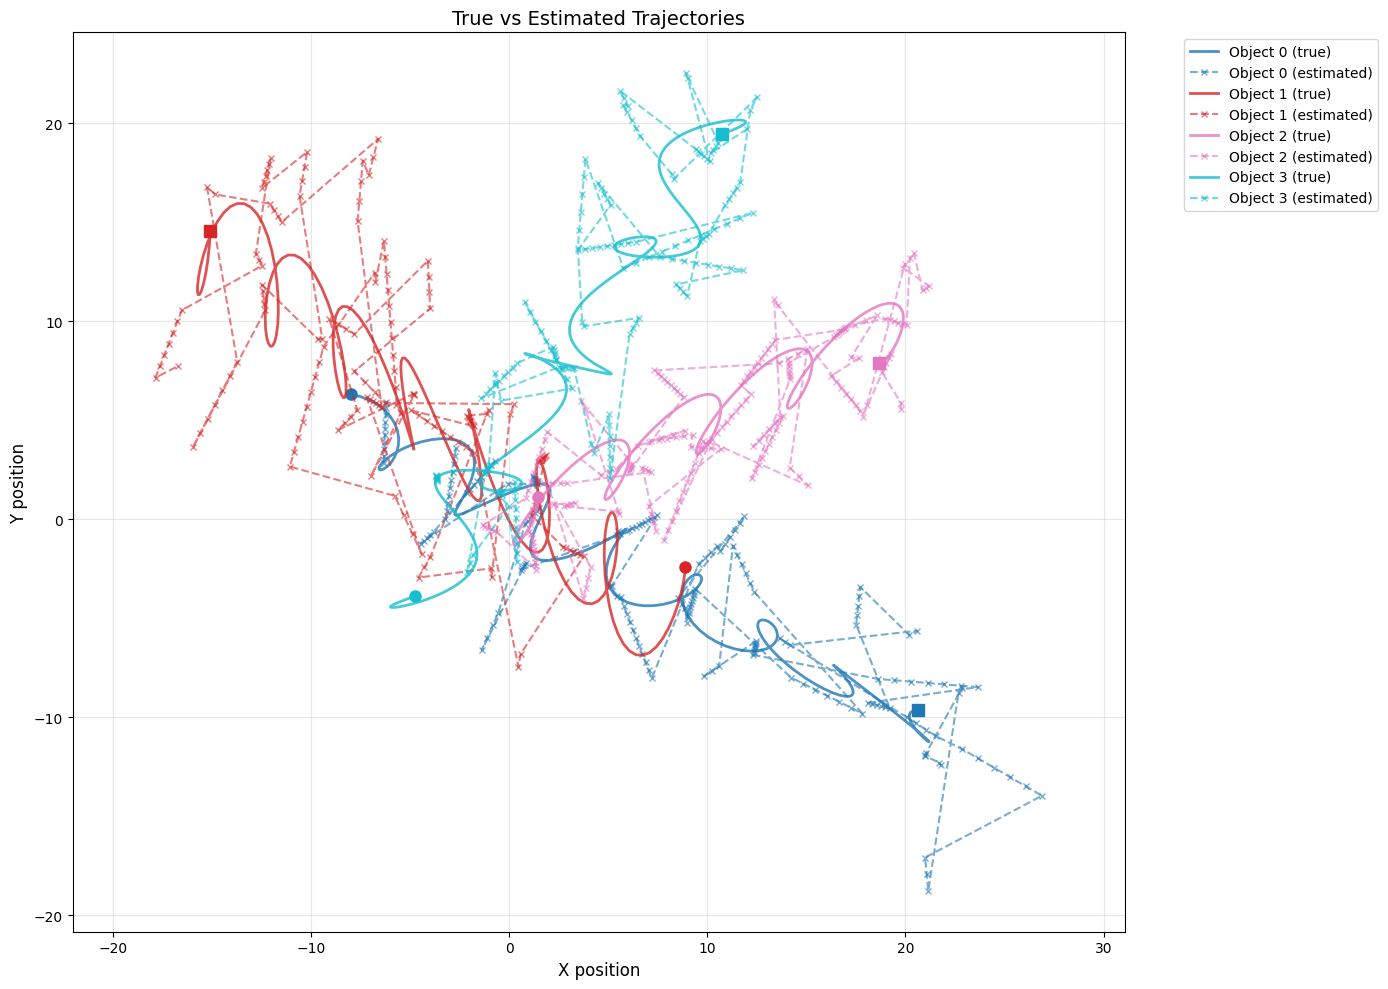


CONF: Balanced noise
TRACKING EXPERIMENT RESULTS
Timesteps: 200, Objects: 4
Noise levels: pos=0.2, yaw=0.1, size=0.05
Tracker params: max_age=10, threshold=0.7, min_hits=3
------------------------------------------------------------
Matched assignments: 484
Position MAE: 0.1488
Velocity MAE: 0.2174
Matching accuracy: 100.00% (484/484)
ID switches: 142


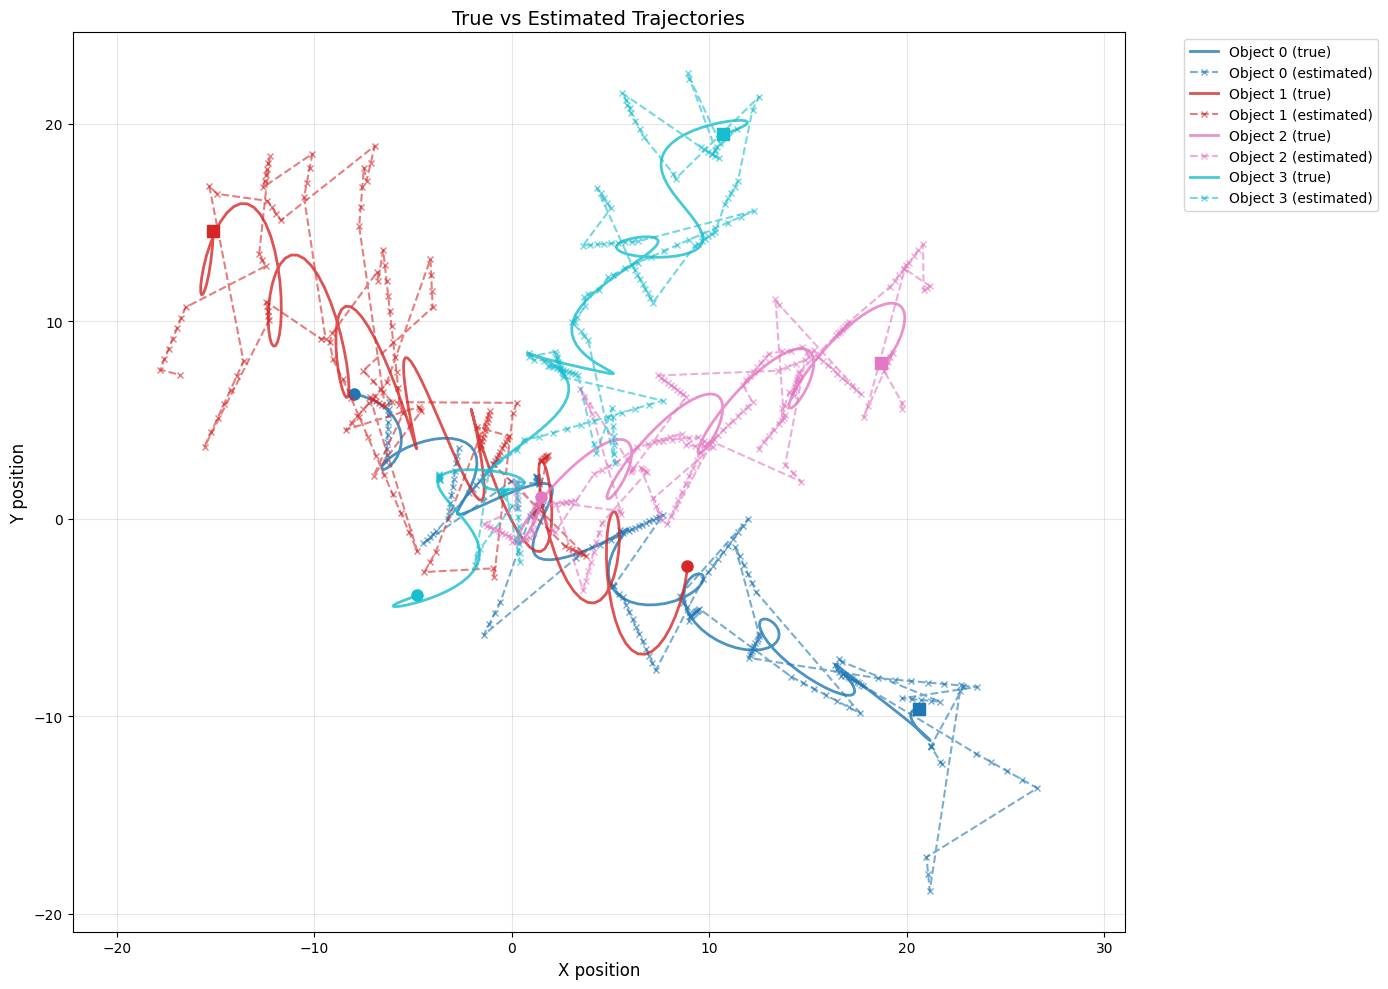


CONF: High yaw noise
TRACKING EXPERIMENT RESULTS
Timesteps: 200, Objects: 4
Noise levels: pos=0.2, yaw=0.1, size=0.05
Tracker params: max_age=10, threshold=0.7, min_hits=3
------------------------------------------------------------
Matched assignments: 486
Position MAE: 0.1485
Velocity MAE: 0.2166
Matching accuracy: 100.00% (486/486)
ID switches: 140


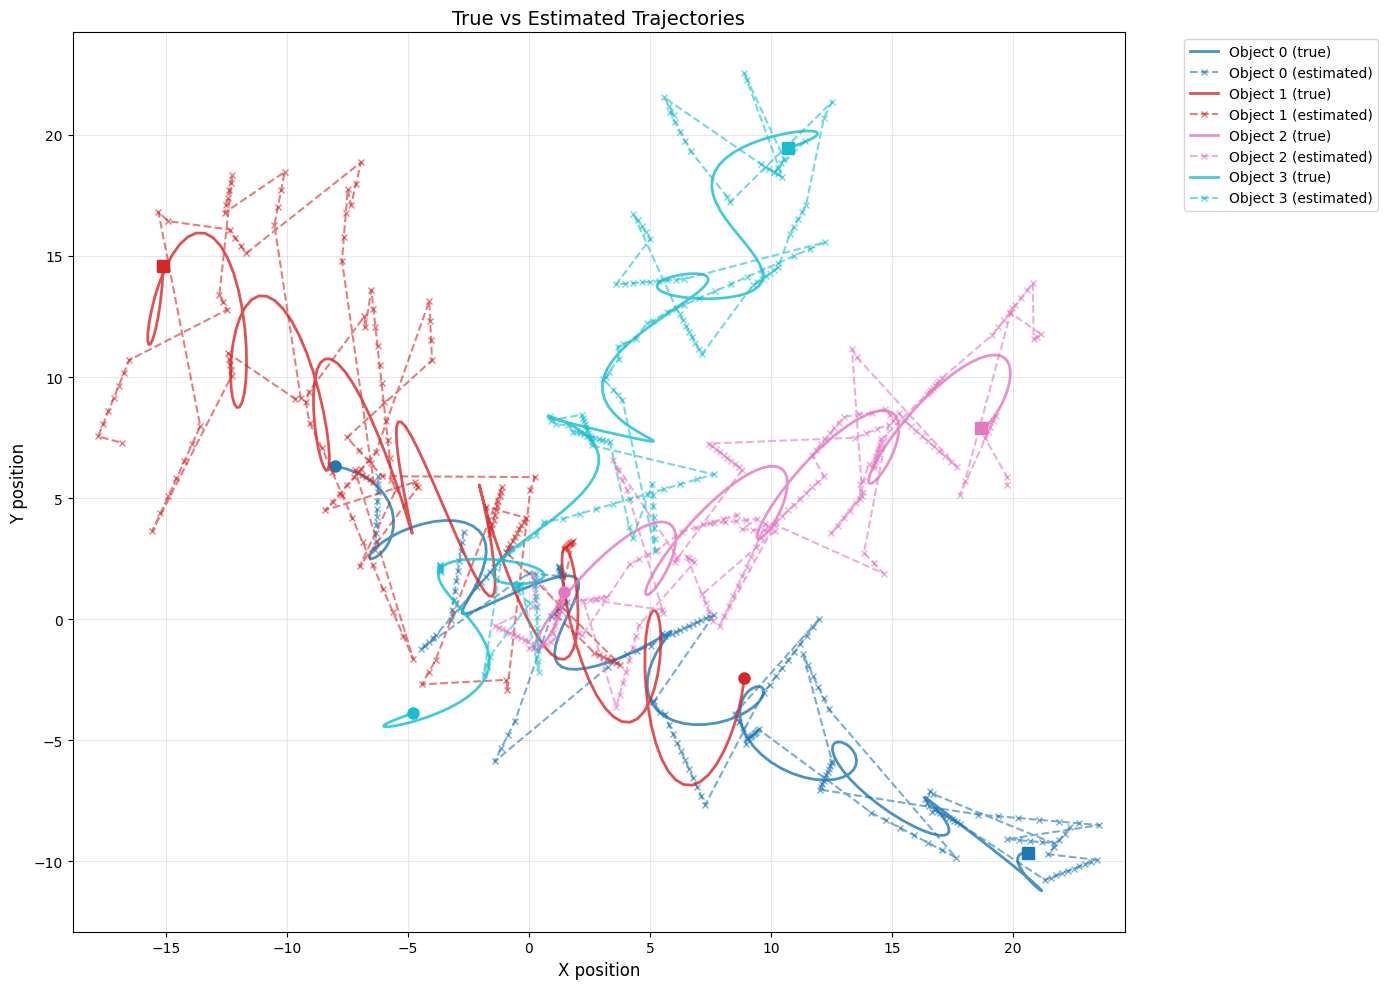


CONF: Low yaw noise
TRACKING EXPERIMENT RESULTS
Timesteps: 200, Objects: 4
Noise levels: pos=0.2, yaw=0.1, size=0.05
Tracker params: max_age=10, threshold=0.7, min_hits=3
------------------------------------------------------------
Matched assignments: 486
Position MAE: 0.1492
Velocity MAE: 0.2166
Matching accuracy: 100.00% (486/486)
ID switches: 139


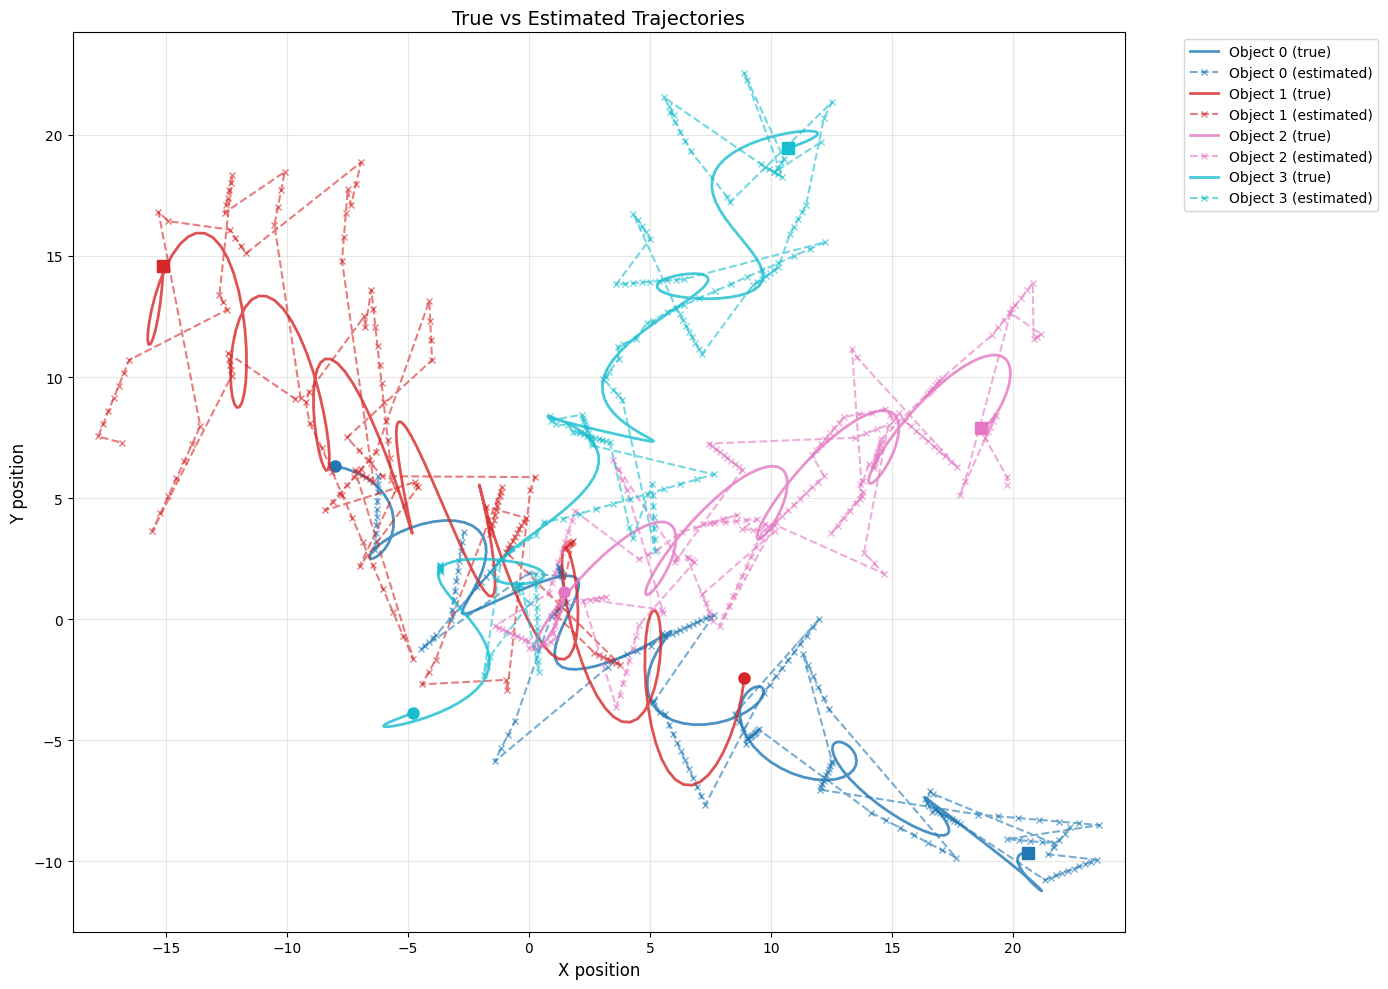


CONF: Extremely rigid (almost doesn't believe the measurements)
TRACKING EXPERIMENT RESULTS
Timesteps: 200, Objects: 4
Noise levels: pos=0.2, yaw=0.1, size=0.05
Tracker params: max_age=10, threshold=0.7, min_hits=3
------------------------------------------------------------
Matched assignments: 472
Position MAE: 0.1581
Velocity MAE: 0.1978
Matching accuracy: 100.00% (472/472)
ID switches: 150


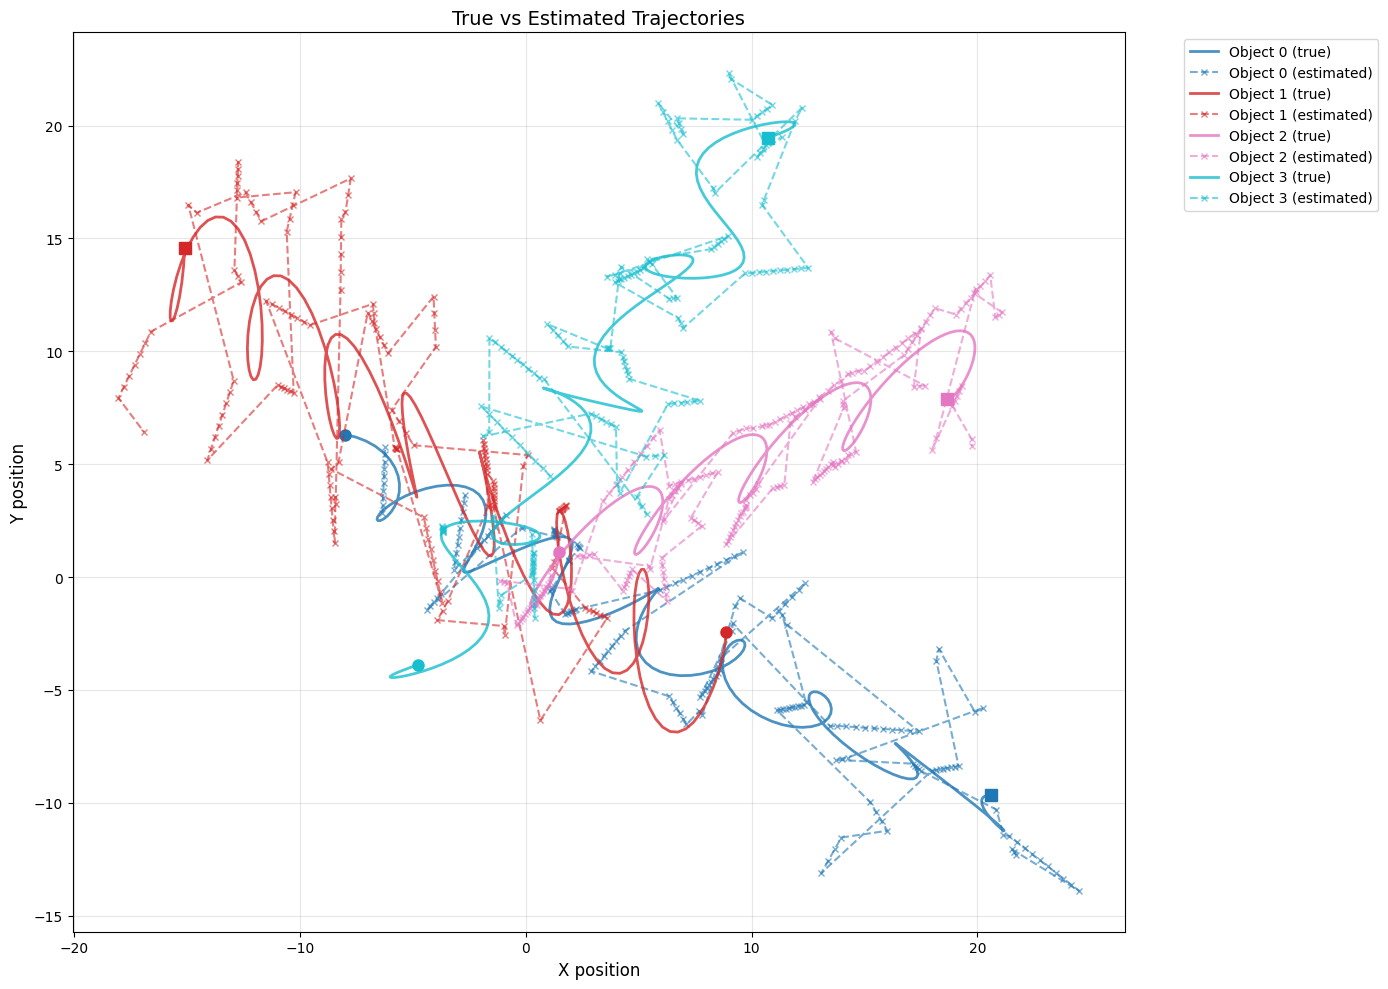


CONF: Extremely flexible model (completely trusts measurements)
TRACKING EXPERIMENT RESULTS
Timesteps: 200, Objects: 4
Noise levels: pos=0.2, yaw=0.1, size=0.05
Tracker params: max_age=10, threshold=0.7, min_hits=3
------------------------------------------------------------
Matched assignments: 471
Position MAE: 0.1569
Velocity MAE: 0.2008
Matching accuracy: 100.00% (471/471)
ID switches: 145


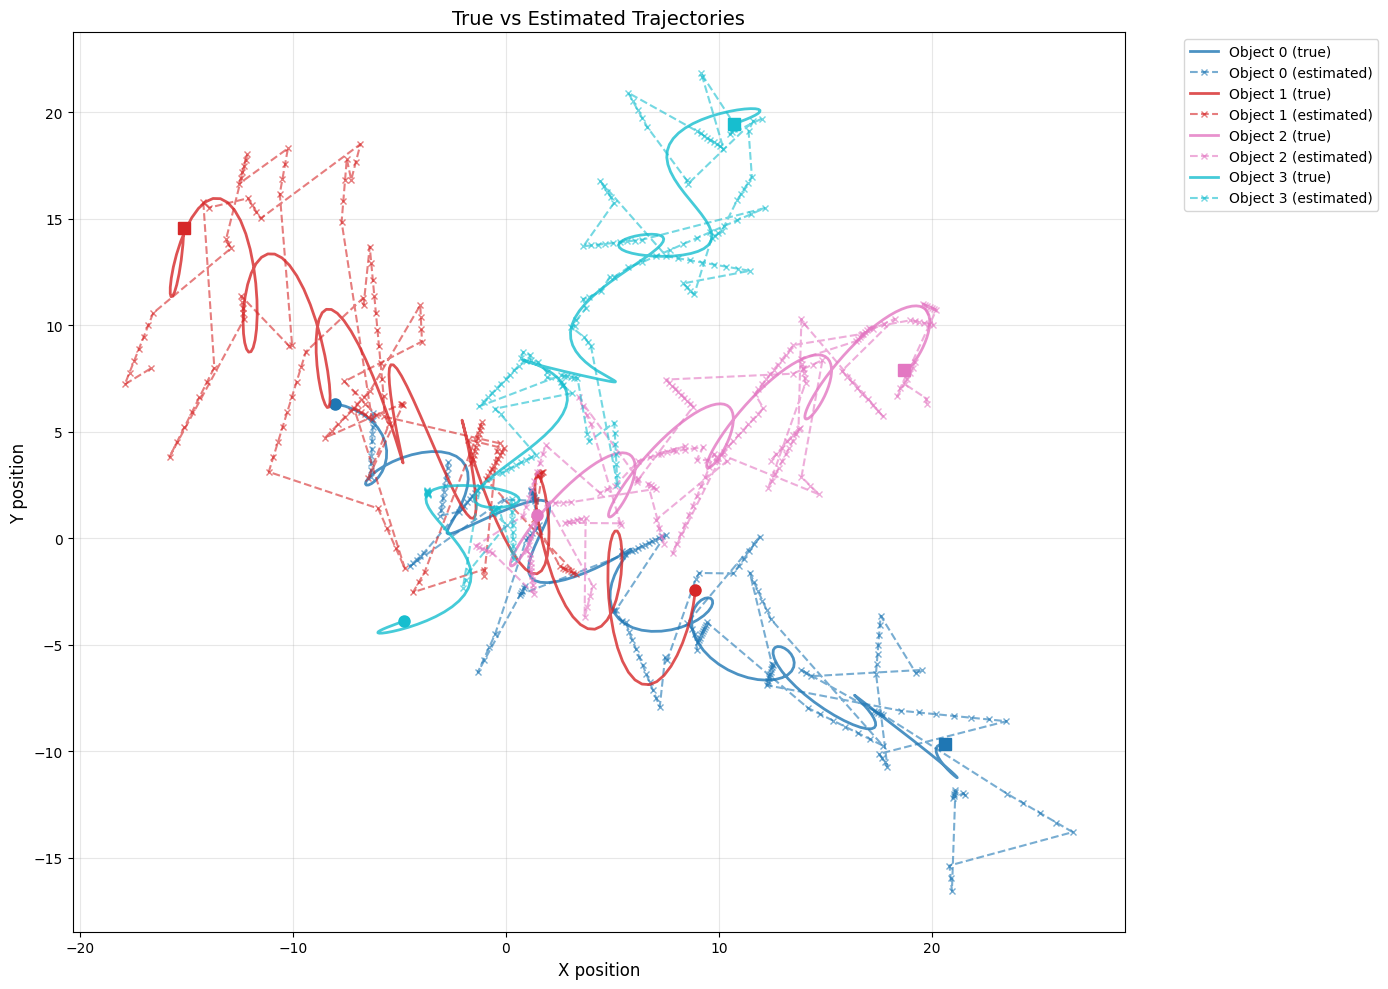

In [115]:
print('STAR EXCPERIMENTS')
results, _ = run_noise_experiments(T=200)

In [116]:
print('COMPARE TABLE')
print('='*100)
comparison_df = create_comparison_report(results)
comparison_df

COMPARE TABLE


,Conf,MAE pos,MAE vel,MAE acc%,ID switches
0,Low model noise / high detector noise,0.145843,0.188893,100.0,145
1,High model noise / low detector noise,0.154088,0.225370,100.0,157
2,Balanced noise,0.148813,0.217363,100.0,142
3,High yaw noise,0.148544,0.216624,100.0,140
4,Low yaw noise,0.149150,0.216563,100.0,139
5,Extremely rigid (almost doesn't believe the me...,0.158080,0.197754,100.0,150
6,Extremely flexible model (completely trusts me...,0.156856,0.200819,100.0,145


In [117]:
print_analysis_conclusions(results)


PRINT CONCLUSION


,conf,assoc_stability,id_switches,id_issue,yaw_behavior,tracker_char,matching_accuracy
0,Low model noise / high detector noise,GREEN (association >95%),145,YELLOW (much switches: 145),NORMAL,"Hard (smooths out noise, but can be delayed)",100.0%
1,High model noise / low detector noise,GREEN (association >95%),157,YELLOW (much switches: 157),NORMAL,"Flexible (responds quickly, but can shake)",100.0%
2,Balanced noise,GREEN (association >95%),142,YELLOW (much switches: 142),NORMAL,Balanced,100.0%
3,High yaw noise,GREEN (association >95%),140,YELLOW (much switches: 140),YELLOW (high variability),Balanced,100.0%
4,Low yaw noise,GREEN (association >95%),139,YELLOW (much switches: 139),"GREEN (stable, but possibly delayed)",Balanced,100.0%
5,Extremely rigid (almost doesn't believe the me...,GREEN (association >95%),150,YELLOW (much switches: 150),NORMAL,"Hard (smooths out noise, but can be delayed)",100.0%
6,Extremely flexible model (completely trusts me...,GREEN (association >95%),145,YELLOW (much switches: 145),NORMAL,"Flexible (responds quickly, but can shake)",100.0%


## Вывод

### 1. Общая информация

Было проведено 7 экспериментов с различными комбинациями матриц шума процесса (Q) и измерений (R) для оценки поведения фильтра Калмана в задаче трекинга объектов. Во всех экспериментах использовалось 3 объекта, точность ассоциации составила **100%** во всех конфигурациях.

### 2. Сводная таблица результатов

| Конфигурация | MAE позиции | MAE скорости | ID switches | Характеристика трекера |
|--------------|-------------|--------------|-------------|------------------------|
| Low model noise / high detector noise | 0.1458 | 0.1889 | 145 | Hard |
| High model noise / low detector noise | 0.1541 | 0.2254 | 157 | Flexible |
| Balanced noise | 0.1488 | 0.2174 | 142 | Balanced |
| High yaw noise | 0.1485 | 0.2166 | 140 | Balanced |
| Low yaw noise | 0.1492 | 0.2166 | 139 | Balanced |
| Extremely rigid | 0.1581 | 0.1978 | 150 | Hard |
| Extremely flexible | 0.1569 | 0.2008 | 145 | Flexible |

---

### 3. Анализ по каждой конфигурации

#### **3.1. Low model noise / high detector noise** (Низкий шум модели / высокий шум детектора)

| Метрика | Значение | Оценка |
|---------|----------|--------|
| MAE позиции | 0.1458 |**Лучший результат** |
| MAE скорости | 0.1889 |**Лучший результат** |
| ID switches | 145 | Средний показатель |
| Характеристика | Hard | Жесткий |

**Вывод:** 
- **Наиболее точный трекер** по позиции и скорости
- Хорошо сглаживает шум детектора благодаря низкому Q
- Высокое доверие к модели приводит к игнорированию шумных измерений
- **Поведение:** Плавные траектории, устойчив к шуму, но может запаздывать при резких поворотах

#### **3.2. High model noise / low detector noise** (Высокий шум модели / низкий шум детектора)

| Метрика | Значение | Оценка |
|---------|----------|--------|
| MAE позиции | 0.1541 |Худший результат |
| MAE скорости | 0.2254 |**Худший результат** |
| ID switches | 157 |**Худший результат** |
| Характеристика | Flexible | Гибкий |

**Вывод:**
- **Наихудшая точность** среди всех конфигураций
- Максимальное количество переключений ID (157)
- Слишком гибкий трекер "дергается" вслед за шумом
- **Поведение:** Шумоподобное дрожание траекторий, низкая стабильность

---

#### **3.3. Balanced noise** (Сбалансированные шумы)

| Метрика | Значение | Оценка |
|---------|----------|--------|
| MAE позиции | 0.1488 | Хороший результат |
| MAE скорости | 0.2174 | Средний результат |
| ID switches | 142 | Хороший результат |
| Характеристика | Balanced | Сбалансированный |

**Вывод:**
- Хороший компромисс между точностью и стабильностью
- Одно из наименьших количеств ID switches
- **Поведение:** Уверенное слежение без резких скачков

---

#### **3.4. High yaw noise** (Завышенные шумы yaw)

| Метрика | Значение | Оценка |
|---------|----------|--------|
| MAE позиции | 0.1485 | Хороший результат |
| MAE скорости | 0.2166 | Средний результат |
| ID switches | 140 | **Лучший результат** |
| Yaw поведение | YELLOW | Высокая вариативность |

**Вывод:**
- **Минимальное количество ID switches** (140)
- Высокая вариативность угла yaw
- **Поведение:** Трекер теряется в оценке ориентации, но хорош в идентичности объектов

---

#### **3.5. Low yaw noise** (Заниженные шумы yaw)

| Метрика | Значение | Оценка |
|---------|----------|--------|
| MAE позиции | 0.1492 | Хороший результат |
| MAE скорости | 0.2166 | Средний результат |
| ID switches | 139 | **Лучший результат** |
| Yaw поведение | GREEN | Стабильный |

**Вывод:**
- **Абсолютный минимум ID switches** (139)
- Стабильная оценка угла yaw
- Возможно небольшое запаздывание при изменении ориентации
- **Поведение:** Уверенное слежение, объекты не путаются

---

#### **3.6. Extremely rigid** (Экстремально жесткая модель)

| Метрика | Значение | Оценка |
|---------|----------|--------|
| MAE позиции | 0.1581 | **Худший результат** |
| MAE скорости | 0.1978 | Хороший результат |
| ID switches | 150 | Плохой результат |
| Характеристика | Hard | Жесткий |

**Вывод:**
- **Наихудшая точность позиции**
- Хорошая точность скорости (модель доверяет своим предсказаниям)
- **Поведение:** Сильное сглаживание, трекер не успевает за изменениями

---

#### **3.7. Extremely flexible** (Экстремально гибкая модель)

| Метрика | Значение | Оценка |
|---------|----------|--------|
| MAE позиции | 0.1569 | Плохой результат |
| MAE скорости | 0.2008 | Средний результат |
| ID switches | 145 | Средний результат |
| Характеристика | Flexible | Гибкий |

**Вывод:**
- Низкая точность позиции
- Трекер слишком доверяет шумным измерениям
- **Поведение:** Дрожание, шумоподобное следование за детекциями

### 4. Общие выводы

Комбинации с наиболее плавными траекториями:
- **Low model noise / high detector noise** (0.1458 MAE) — наиболее плавные траектории благодаря высокому доверию к модели
- **Extremely rigid** — слишком плавные, с запаздыванием

Комбинации, которые приводят к ошибкам ассоциации:
  - **High model noise / low detector noise** (157 switches)
  - **Extremely rigid** (150 switches)

Комбинации, усиливающие или уменьшающие ошибку yaw:
- **High yaw noise** — высокая вариативность, но хорошая ассоциация
- **Low yaw noise** — стабильный yaw, лучшая ассоциация

Комбинации с слишком жестким или слишком нервным треком:

| Тип | Конфигурация | Поведение |
|-----|--------------|-----------|
| **Слишком жесткий** | Extremely rigid | Запаздывание, игнорирование измерений |
| **Слишком нервный** | High model noise / low detector noise | Дрожание, ложные движения |
| **Оптимальный** | Low yaw noise / Balanced | Плавность + точность |

### 5. Итоговый вывод

| Сценарий | Рекомендуемая конфигурация | Причина |
|----------|---------------------------|---------|
| **Высокоточное позиционирование** | Low model noise / high detector noise | Лучшая точность позиции и скорости |
| **Минимизация перепутывания объектов** | Low yaw noise | Минимум ID switches (139) |
| **Стабильная оценка ориентации** | Low yaw noise | Стабильный yaw |
| **Быстро движущиеся объекты** | Balanced или Low model noise | Компромисс между скоростью реакции и точностью |
| **Шумный детектор** | Low model noise / high detector noise | Игнорирует шум, доверяет модели |
| **Точный детектор** | High model noise / low detector noise | Доверяет точным измерениям |

**Лучшая конфигурация:** **Balanced noise** или **Low yaw noise**

Эти конфигурации показывают:
- Хорошую точность позиции (0.148-0.149)
- Минимальное количество ID switches (139-142)
- Стабильное поведение без перекосов в жесткость или гибкость

**Худшая конфигурация:** **High model noise / low detector noise**
- Максимальные ошибки
- Наибольшее количество перепутываний объектов
- Нестабильное поведение